# 循环神经网络的简洁实现


## 环境配置


In [1]:
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor with interal format")
import pypto
import torch
from torch import nn
from torch.nn import functional as F
import torch_npu
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('torch_npu.env').setLevel(logging.ERROR)
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()


## 练习8.6.1

**题目：** 尝试使用高级API，能使循环神经网络模型过拟合吗？

**解答：**
使用小数据集、高学习率（lr=10），并训练较多周期（num_epochs=500），可以显著过拟合。训练困惑度会飙升至极大值，而预测出的文本变成连续重复的单个字符 "eeeeeeee..."，说明模型已经崩溃，只能输出它认为最"安全"的预测。

以下使用 `torch` 编程：



In [2]:
import torch
from torch import nn
from torch.nn import functional as F
from src.utils import RNNModel, load_data_time_machine, train_ch8, try_gpu

batch_size, num_steps = 32, 35
from src.utils import load_data_time_machine
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

num_hiddens = 256
rnn_layer = nn.RNN(len(vocab), num_hiddens)

torch_device = try_gpu()
net = RNNModel(rnn_layer, vocab_size=len(vocab))
net = net.to(torch_device)
num_epochs, lr = 500, 10
train_ch8(net, train_iter, vocab, lr, num_epochs, torch_device, use_plot=False)


time travellerrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr
  [epoch 10/500] perplexity=24839284091785018454841491456.0


time travellernrynrynrynrynrynrynrynrynrynrynrynrynrynrynrynrynr
  [epoch 20/500] perplexity=2936910706065058.0


time travelleroeeoeeoeeoeeoeeoeeoeeoeeoeeoeeoeeoeeoeeoeeoeeoeeoe
  [epoch 30/500] perplexity=1655744710914474752.0


time travelleren en en en en en en en en en en en en en en en en
  [epoch 40/500] perplexity=793932951044317696.0


time travellerherherherherherherherherherherherherherherherherhe
  [epoch 50/500] perplexity=57756981060056296.0


...

time travelleryoyoyoyoyoyoyoyoyoyoyoyoyoyoyoyoyoyoyoyoyoyoyoyoyo
  [epoch 460/500] perplexity=11241139205658118597013143552.0


time travellerl l l l l l l l l l l l l l l l l l l l l l l l l 
  [epoch 470/500] perplexity=2535350700545662498071642112.0


time travellere e e e e e e e e e e e e e e e e e e e e e e e e 
  [epoch 480/500] perplexity=15354938381281310.0


time travelleraoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoao
  [epoch 490/500] perplexity=954067424563344263706836992.0


time travelleraiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiai
  [epoch 500/500] perplexity=2835892066238788009984.0
困惑度 2835892066238788009984.0, 89100.9 词元/秒 cpu
time travelleraiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiai
travelleriaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaiaia


使用 `PyPTO` 编程（PyPTO 输出层 + nn.RNN）：



In [3]:
import time as _time
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

class TorchRNNModel(nn.Module):
    def __init__(self, rnn_layer, vocab_size, device=None):
        super().__init__()
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.device = device if device is not None else next(rnn_layer.parameters()).device
        nd = 2 if self.rnn.bidirectional else 1
        out_features = self.rnn.hidden_size * nd
        self.W_hq = nn.Parameter(torch.randn(out_features, vocab_size, device=self.device) * 0.01)
        self.b_q = nn.Parameter(torch.zeros(vocab_size, device=self.device))

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(device=self.device, dtype=torch.float32)
        Y, state = self.rnn(X, state)
        Y_flat = Y.reshape((-1, Y.shape[-1]))
        orig_m = Y_flat.shape[0]
        if orig_m % 16 != 0:
            pad_m = 16 - orig_m % 16
            Y_flat_padded = F.pad(Y_flat, (0, 0, 0, pad_m))
            out_padded = PyPTOBiasAdd.apply(PyPTOMatmul.apply(Y_flat_padded, self.W_hq), self.b_q)
            output = out_padded[:orig_m, :]
        else:
            output = PyPTOBiasAdd.apply(PyPTOMatmul.apply(Y_flat, self.W_hq), self.b_q)
        return output, state

    def begin_state(self, device=None, batch_size=1):
        if device is None:
            device = next(self.parameters()).device
        nd = 2 if self.rnn.bidirectional else 1
        if isinstance(self.rnn, nn.LSTM):
            return (torch.zeros(nd * self.rnn.num_layers, batch_size, self.rnn.hidden_size, device=device),
                    torch.zeros(nd * self.rnn.num_layers, batch_size, self.rnn.hidden_size, device=device))
        return torch.zeros(nd * self.rnn.num_layers, batch_size, self.rnn.hidden_size, device=device)

num_hiddens = 256
rnn_layer = nn.RNN(len(vocab), num_hiddens)
net = TorchRNNModel(rnn_layer, vocab_size=len(vocab), device=device).to(device)

# JIT warmup for PyPTO output layer
print('正在编译 PyPTO kernel...')
t0 = _time.time()
state = net.begin_state(device, batch_size)
X = next(iter(train_iter))[0].to(device)
Y = F.one_hot(X.T.long(), len(vocab)).to(device=device, dtype=torch.float32)
rnn_out, _ = net.rnn(Y, state)
_ = PyPTOBiasAdd.apply(PyPTOMatmul.apply(rnn_out.reshape((-1, rnn_out.shape[-1])), net.W_hq), net.b_q)
print(f'编译完成，耗时 {_time.time() - t0:.0f} 秒')

num_epochs, lr = 500, 10
train_ch8(net, train_iter, vocab, lr, num_epochs, device, use_plot=False)


正在编译 PyPTO kernel...


编译完成，耗时 5 秒


time traveller                                                  
  [epoch 10/500] perplexity=274093283860580990976.0


time travelleroooooooooooooooooooooooooooooooooooooooooooooooooo
  [epoch 20/500] perplexity=246027698111562470533115108392960.0


time travellerihihihihihihihihihihihihihihihihihihihihihihihihih
  [epoch 30/500] perplexity=484523302861825554513920.0


...

time travellert  et  et  et  et  et  et  et  et  et  et  et  et 
  [epoch 460/500] perplexity=2660794700303370240.0


time travellerttslttslttslttslttslttslttslttslttslttslttslttsltt
  [epoch 470/500] perplexity=193327082474546240.0


time travellerooaiooaiooaiooaiooaiooaiooaiooaiooaiooaiooaiooaioo
  [epoch 480/500] perplexity=5632278081618143.0


time travellerdeeddeeddeeddeeddeeddeeddeeddeeddeeddeeddeeddeedde
  [epoch 490/500] perplexity=20722300494068676.0


time travellerancaancaancaancaancaancaancaancaancaancaancaancaan
  [epoch 500/500] perplexity=59668906749099544.0
困惑度 59668906749099544.0, 73541.5 词元/秒 npu:0
time travellerancaancaancaancaancaancaancaancaancaancaancaancaan
travelleraancaancaancaancaancaancaancaancaancaancaancaancaa


## 练习8.6.2

**题目：** 如果在循环神经网络模型中增加隐藏层的数量会发生什么？能使模型正常工作吗？

**解答：**
增加隐藏层数量可以增加模型容量，使训练困惑度降低（如从 1.3 降到 1.0），但也会显著降低训练速度（torch/CPU 版从 75687 降到 24937 词元/秒，PyPTO/NPU 版从 89608 降到 31140 词元/秒），且当层数过多时（如 20 层），模型可能因梯度消失或梯度爆炸而无法有效训练，困惑度反而上升（17.4）。需要在模型容量和计算效率之间取得平衡。



以下使用 `torch` 编程：



In [4]:
import torch
from torch import nn
from src.utils import load_data_time_machine, train_ch8, try_gpu

batch_size, num_steps = 32, 100
from src.utils import load_data_time_machine
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

torch_device = try_gpu()

# num_layers=1
rnn_layer_1 = nn.RNN(len(vocab), 256, num_layers=1)
net_1 = RNNModel(rnn_layer_1, len(vocab)).to(torch_device)
train_ch8(net_1, train_iter, vocab, 1.0, 500, torch_device, use_plot=False)

# num_layers=3
rnn_layer_3 = nn.RNN(len(vocab), 256, num_layers=3)
net_3 = RNNModel(rnn_layer_3, len(vocab)).to(torch_device)
train_ch8(net_3, train_iter, vocab, 1.0, 500, torch_device, use_plot=False)

# num_layers=20
rnn_layer_20 = nn.RNN(len(vocab), 256, num_layers=20)
net_20 = RNNModel(rnn_layer_20, len(vocab)).to(torch_device)
train_ch8(net_20, train_iter, vocab, 1.0, 500, torch_device, use_plot=False)


time traveller the the the the the the the the the the the the t
  [epoch 10/500] perplexity=15.2


time travellere the the the the the the the the the the the the 
  [epoch 20/500] perplexity=12.0


time traveller the the the the the the the the the the the the t
  [epoch 30/500] perplexity=10.5


time traveller the the the the the the the the the the the the t
  [epoch 40/500] perplexity=9.8


time traveller the the the the the the the the the the the the t
  [epoch 50/500] perplexity=9.5


...

time traveller                                                  
  [epoch 480/500] perplexity=17.4


time traveller                                                  
  [epoch 490/500] perplexity=17.4


time traveller                                                  
  [epoch 500/500] perplexity=17.4
困惑度 17.4, 4863.1 词元/秒 cpu


time traveller                                                  


traveller                                                  


使用 `PyPTO` 编程（PyPTO 输出层 + nn.RNN）：



### num_layers=1


In [5]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd

batch_size, num_steps = 32, 100
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

# 注：TorchRNNModel 在练习 8.6.1 的 PyPTO cell 中定义，此处引用
# num_layers=1
print('=== num_layers=1 ===')
rnn_layer_1 = nn.RNN(len(vocab), 256, num_layers=1)
net_1 = TorchRNNModel(rnn_layer_1, len(vocab), device=device).to(device)
# JIT 预热
X_w, y_w = next(iter(train_iter))
s = net_1.begin_state(device, batch_size)
y_hat_w, _ = net_1(X_w.to(device), s)
l_w = nn.CrossEntropyLoss()(y_hat_w, y_w.T.reshape(-1).long().to(device))
l_w.backward(); net_1.zero_grad()

train_ch8(net_1, train_iter, vocab, 1.0, 500, device, use_plot=False)


=== num_layers=1 ===


time travellere tee tee tee tee tee tee tee tee tee tee tee tee 
  [epoch 10/500] perplexity=16.4


time travellere the the the the the the the the the the the the 
  [epoch 20/500] perplexity=13.0


time travellere the thane the thane the thane the thane the than
  [epoch 30/500] perplexity=11.2


time traveller the the the the the the the the the the the the t
  [epoch 40/500] perplexity=10.2


...

time traveller smiled round at us the repres os the other wayou 
  [epoch 460/500] perplexity=1.4


time traveller smiled round ather canthrthal stine vara we has a
  [epoch 470/500] perplexity=1.4


time traveller comenis begond ssisteonet ofact uinely in the wil
  [epoch 480/500] perplexity=1.3


time traveller pmoteed bone thenet satd med and long the grime t
  [epoch 490/500] perplexity=1.3


time traveller smiled are yon s all him the ge movesp another wi
  [epoch 500/500] perplexity=1.4
困惑度 1.4, 89608.5 词元/秒 npu:0
time traveller smiled are yon s all him the ge movesp another wi
traveller act andil theer but is that shich very ulen thin 


### num_layers=3


In [6]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd

batch_size, num_steps = 32, 100
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

# 注：TorchRNNModel 在练习 8.6.1 的 PyPTO cell 中定义，此处引用
# num_layers=3
print('=== num_layers=3 ===')
rnn_layer_3 = nn.RNN(len(vocab), 256, num_layers=3)
net_3 = TorchRNNModel(rnn_layer_3, len(vocab), device=device).to(device)
# JIT 预热
X_w3, y_w3 = next(iter(train_iter))
s3 = net_3.begin_state(device, batch_size)
y_hat_w3, _ = net_3(X_w3.to(device), s3)
l_w3 = nn.CrossEntropyLoss()(y_hat_w3, y_w3.T.reshape(-1).long().to(device))
l_w3.backward(); net_3.zero_grad()

train_ch8(net_3, train_iter, vocab, 1.0, 500, device, use_plot=False)


=== num_layers=3 ===


time traveller                                                  
  [epoch 10/500] perplexity=17.5


time traveller the than the than the than the than the than the 
  [epoch 20/500] perplexity=14.2


time travellere tha tha tha tha tha tha tha tha tha tha tha tha 
  [epoch 30/500] perplexity=12.5


time travellere the the the the the the the the the the the the 
  [epoch 40/500] perplexity=10.7


...

time traveller after the pauserequired for the proper assimilati
  [epoch 470/500] perplexity=1.1


time travelleryou can show black is white by argument said filby
  [epoch 480/500] perplexity=1.0


time traveller for so it will be convenient to speak of himwas e
  [epoch 490/500] perplexity=1.0


time traveller smiled are you sure we can move freely inspace ri
  [epoch 500/500] perplexity=1.0
困惑度 1.0, 31140.5 词元/秒 npu:0
time traveller smiled are you sure we can move freely inspace ri


traveller for so it will be convenient to speak of himwas e


### num_layers=20


In [7]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd

batch_size, num_steps = 32, 100
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

# 注：TorchRNNModel 在练习 8.6.1 的 PyPTO cell 中定义，此处引用
# num_layers=20
print('=== num_layers=20 ===')
rnn_layer_20 = nn.RNN(len(vocab), 256, num_layers=20)
net_20 = TorchRNNModel(rnn_layer_20, len(vocab), device=device).to(device)
# JIT 预热
X_w20, y_w20 = next(iter(train_iter))
s20 = net_20.begin_state(device, batch_size)
y_hat_w20, _ = net_20(X_w20.to(device), s20)
l_w20 = nn.CrossEntropyLoss()(y_hat_w20, y_w20.T.reshape(-1).long().to(device))
l_w20.backward(); net_20.zero_grad()

train_ch8(net_20, train_iter, vocab, 1.0, 500, device, use_plot=False)


=== num_layers=20 ===


time traveller                                                  
  [epoch 10/500] perplexity=17.8


time traveller                                                  
  [epoch 20/500] perplexity=17.5


time traveller                                                  
  [epoch 30/500] perplexity=17.5


time traveller                                                  
  [epoch 40/500] perplexity=17.5


...

time traveller                                                  
  [epoch 480/500] perplexity=17.4


time traveller                                                  
  [epoch 490/500] perplexity=17.4


time traveller                                                  
  [epoch 500/500] perplexity=17.4
困惑度 17.4, 4743.9 词元/秒 npu:0


time traveller                                                  


traveller                                                  


## 练习8.6.3

**题目：** 尝试使用循环神经网络实现 8.1 节的自回归模型。

**解答：**
将 08.1 节的正弦序列预测问题建模为 sequence-to-sequence 任务，使用 nn.RNN 替代 MLP。RNN 的隐状态可以穿越时间步，能够捕捉序列中的长程依赖关系，理论上比固定窗口 $\tau=4$ 的 MLP 更适合序列预测。



以下使用 `torch` 编程：



epoch 1, loss: 0.065949


epoch 2, loss: 0.057228


epoch 3, loss: 0.061274


epoch 4, loss: 0.058872


epoch 5, loss: 0.072181


...

epoch 46, loss: 0.055264


epoch 47, loss: 0.063225


epoch 48, loss: 0.078192


epoch 49, loss: 0.058449


epoch 50, loss: 0.057942


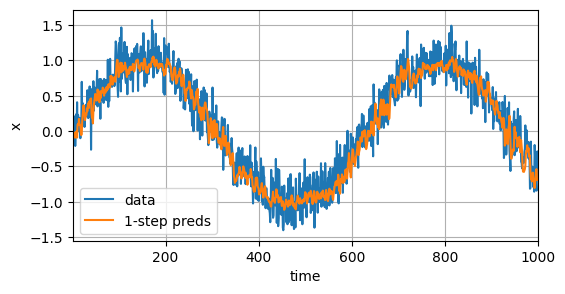

In [8]:
from src.utils import evaluate_loss, load_array, plot, try_gpu
import torch
from torch import nn

# 数据生成
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))

tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = load_array((features[:n_train], labels[:n_train]), 
                             batch_size, is_train=True)

# 构建 RNN 自回归模型
class RNNAutoRegressive(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=4, hidden_size=200)
        self.linear = nn.Linear(200, 1)
    
    def forward(self, X):
        # X: (batch_size, tau), 增加 seq_len 维度
        out, _ = self.rnn(X.unsqueeze(0))
        return self.linear(out.reshape((-1, out.shape[-1])))

loss = nn.MSELoss(reduction='none')

lr = 0.01
torch_device = try_gpu()
net = RNNAutoRegressive().to(torch_device)
trainer = torch.optim.Adam(net.parameters(), lr)

epochs = 50
for epoch in range(epochs):
    for X, y in train_iter:
        X, y = X.to(torch_device), y.to(torch_device)
        trainer.zero_grad()
        l = loss(net(X), y)
        l.sum().backward()
        trainer.step()
    print(f'epoch {epoch + 1}, loss: {evaluate_loss(net, train_iter, loss):f}')

# 单步预测
features_device = features.to(torch_device)
onestep_preds = net(features_device).cpu()

plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds.squeeze(1).detach().numpy()], 'time',
         'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))


使用 `PyPTO` 编程（PyPTO 输出层 + nn.RNN）：



正在编译 PyPTO kernel...


编译完成，耗时 9 秒


epoch 1, loss: 0.056531
epoch 2, loss: 0.054926


epoch 3, loss: 0.051593
epoch 4, loss: 0.065375


epoch 5, loss: 0.058126
epoch 6, loss: 0.068427


...

epoch 41, loss: 0.051217
epoch 42, loss: 0.052016


epoch 43, loss: 0.053110
epoch 44, loss: 0.068882


epoch 45, loss: 0.057284
epoch 46, loss: 0.051896


epoch 47, loss: 0.058885
epoch 48, loss: 0.052796


epoch 49, loss: 0.055956
epoch 50, loss: 0.051238


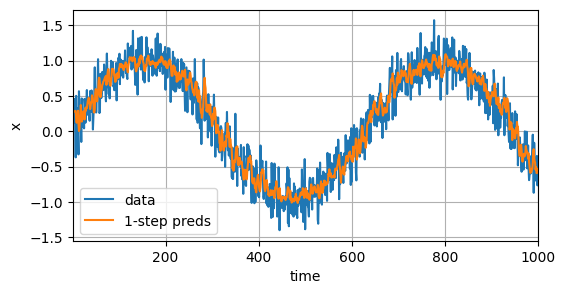

In [9]:
import time as _time
from src.utils import load_array, evaluate_loss, plot
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd

T = 1000
time_vals = torch.arange(1, T + 1, dtype=torch.float32, device=device)
x = torch.sin(0.01 * time_vals) + torch.normal(0, 0.2, (T,), device=device)

tau = 4
features = torch.zeros((T - tau, tau), device=device)
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = load_array((features[:n_train], labels[:n_train]), batch_size, is_train=True)

# PyPTO 自回归 RNN 模型
class RNNAutoRegressive(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=4, hidden_size=200)
        self.W = nn.Parameter(torch.randn(200, 1, device=device) * 0.01)
        self.b = nn.Parameter(torch.zeros(1, device=device))

    def forward(self, X):
        out, _ = self.rnn(X.unsqueeze(0))
        return PyPTOBiasAdd.apply(PyPTOMatmul.apply(out.reshape((-1, out.shape[-1])), self.W), self.b)

loss = nn.MSELoss(reduction='none')

net = RNNAutoRegressive().to(device)
trainer = torch.optim.Adam(net.parameters(), 0.01)

# JIT warmup
print('正在编译 PyPTO kernel...')
t0 = _time.time()
X_warm, y_warm = next(iter(train_iter))
l = loss(net(X_warm), y_warm); l.sum().backward(); net.zero_grad()
print(f'编译完成，耗时 {_time.time() - t0:.0f} 秒')

epochs = 50
for epoch in range(epochs):
    for X, y in train_iter:
        trainer.zero_grad()
        l = loss(net(X), y)
        l.sum().backward()
        trainer.step()
    print(f'epoch {epoch + 1}, loss: {evaluate_loss(net, train_iter, loss):f}')
    
# 单步预测与可视化
onestep_preds = net(features).cpu()

time_cpu = time_vals.cpu()
plot([time_cpu, time_cpu[tau:]],
     [x.detach().cpu().numpy(), onestep_preds.squeeze(1).detach().numpy()], 'time',
     'x', legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3))


---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)

